## Initial Data Inspection and data cleaning: For developing a better understanding of the data, one would generally do the following checks: 
### Whether the data has 

- duplicates
- missing values
- irrelevant(erroneous entries) values
- Outliers



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv(r'C:\Users\hp\1736848608_rolling_stones_spotify (1)\rolling_stones_spotify.csv', index_col = 0)

In [3]:
data.head()

,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1610 entries, 0 to 1609
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1610 non-null   object 
 1   album             1610 non-null   object 
 2   release_date      1610 non-null   object 
 3   track_number      1610 non-null   int64  
 4   id                1610 non-null   object 
 5   uri               1610 non-null   object 
 6   acousticness      1610 non-null   float64
 7   danceability      1610 non-null   float64
 8   energy            1610 non-null   float64
 9   instrumentalness  1610 non-null   float64
 10  liveness          1610 non-null   float64
 11  loudness          1610 non-null   float64
 12  speechiness       1610 non-null   float64
 13  tempo             1610 non-null   float64
 14  valence           1610 non-null   float64
 15  popularity        1610 non-null   int64  
 16  duration_ms       1610 non-null   int64  
dtype

#### Missing Values

In [5]:
data.isnull().sum()

name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

#### Duplicates

In [6]:
data.duplicated(['id']).sum()

0

#### Conversion of date column to datetime type

In [7]:
data.release_date = pd.to_datetime(data.release_date)

In [8]:
data.track_number.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47], dtype=int64)

In [9]:
data.track_number = data.track_number.astype('category')

#### id and uri have only unique values hence can be removed from the data 


In [10]:
new_data = data.drop(columns = ['id', 'uri'])

## Checking for outliers in numerical variables using descriptive stats looking at the difference between the mean and min & max values of variables.

In [11]:
new_data.describe()

,release_date,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,1992-04-23 12:57:14.534161536,0.250475,0.468860,0.792352,0.164170,0.49173,-6.971615,0.069512,126.082033,0.582165,20.788199,257736.488199
min,1964-04-16 00:00:00,0.000009,0.104000,0.141000,0.000000,0.02190,-24.408000,0.023200,46.525000,0.000000,0.000000,21000.000000
25%,1970-09-04 00:00:00,0.058350,0.362250,0.674000,0.000219,0.15300,-8.982500,0.036500,107.390750,0.404250,13.000000,190613.000000
50%,1986-03-24 00:00:00,0.183000,0.458000,0.848500,0.013750,0.37950,-6.523000,0.051200,124.404500,0.583000,20.000000,243093.000000
75%,2017-12-01 00:00:00,0.403750,0.578000,0.945000,0.179000,0.89375,-4.608750,0.086600,142.355750,0.778000,27.000000,295319.750000
max,2022-06-10 00:00:00,0.994000,0.887000,0.999000,0.996000,0.99800,-1.014000,0.624000,216.304000,0.974000,80.000000,981866.000000
std,NaN,0.227397,0.141775,0.179886,0.276249,0.34910,2.994003,0.051631,29.233483,0.231253,12.426859,108333.474920


In [12]:
num_vars = new_data.select_dtypes(include = ['float', 'int']).columns
len(num_vars)

11

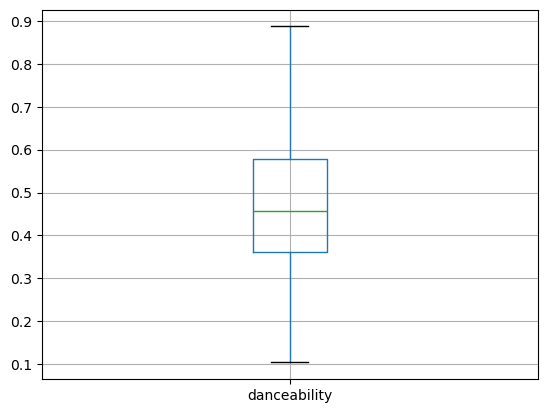

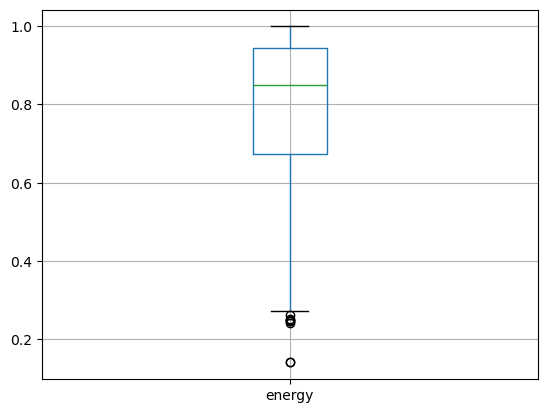

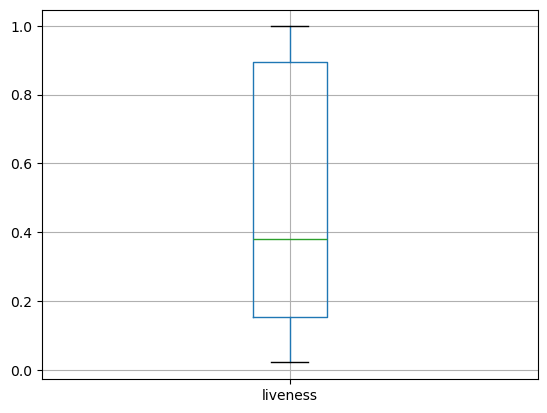

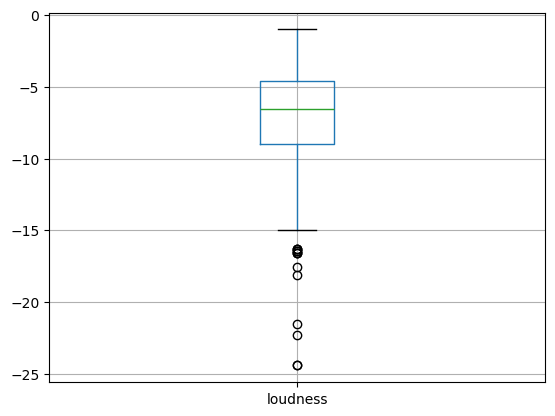

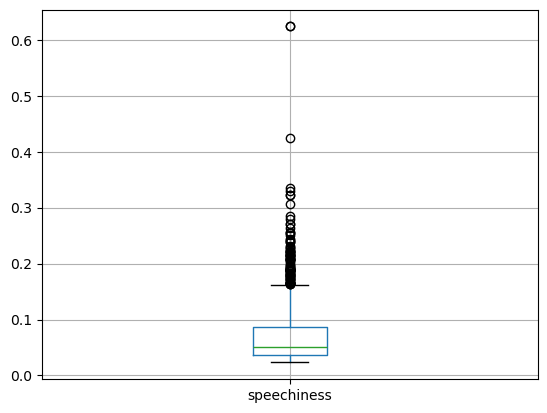

In [13]:
#check for any outlier
new_data[['danceability']].boxplot()
plt.show()
new_data[['energy']].boxplot()
plt.show()
new_data[['liveness']].boxplot()
plt.show()
new_data[['loudness']].boxplot()
plt.show()
new_data[['speechiness']].boxplot()
plt.show()

In [14]:
q1,q3=new_data.loudness.quantile((0.25,0.75))
iqr=q3-q1
min=q1-1.5*iqr
max=q3+1.5*iqr
new_data=new_data[new_data.loudness<max]

In [15]:
q1,q3=new_data.speechiness.quantile((0.25,0.75))
iqr=q3-q1
min=q1-1.5*iqr
max=q3+1.5*iqr
new_data=new_data[new_data.speechiness<max]

In [16]:
q1,q3=new_data.energy.quantile((0.25,0.75))
iqr=q3-q1
min=q1-1.5*iqr
max=q3+1.5*iqr
new_data=new_data[new_data.energy<max]

In [17]:
new_data.isnull().sum()

name                0
album               0
release_date        0
track_number        0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

In [18]:
# Safely drop columns if they exist
new_data.drop(['id'], axis=1, inplace=True, errors='ignore')
new_data.drop(['uri'], axis=1, inplace=True, errors='ignore')

In [19]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1518 entries, 0 to 1609
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   name              1518 non-null   object        
 1   album             1518 non-null   object        
 2   release_date      1518 non-null   datetime64[ns]
 3   track_number      1518 non-null   category      
 4   acousticness      1518 non-null   float64       
 5   danceability      1518 non-null   float64       
 6   energy            1518 non-null   float64       
 7   instrumentalness  1518 non-null   float64       
 8   liveness          1518 non-null   float64       
 9   loudness          1518 non-null   float64       
 10  speechiness       1518 non-null   float64       
 11  tempo             1518 non-null   float64       
 12  valence           1518 non-null   float64       
 13  popularity        1518 non-null   int64         
 14  duration_ms       1518 non-nu

## Which 2 albums would you recommend to anyone based on the number of popular songs in an album? Use necessary visualizations to support your answer.



# 

### top 10 songs

In [20]:
new_data.sort_values('popularity', ascending = False)[['name', 'album','popularity']][:10] 

AttributeError: 'DataFrame' object has no attribute 'sort'

## popularity of an album using avg popularity of the songs

In [ ]:
new_data.groupby(['album'])['popularity'].mean().sort_values(ascending = False)[:10]

### Sticky Fingers (Remastered) and Some Girls are top 2 albums

## What has changed over the years? Perform exploratory data analysis to dive deeper into different features of songs and identify the pattern. Use necessary visualizations to support your points.



In [ ]:
new_data.release_date=pd.to_datetime(new_data.release_date)
new_data['year']=pd.DatetimeIndex(new_data['release_date']).year
new_data['year']

In [ ]:
sns.heatmap(new_data.corr(numeric_only=True),annot=True,annot_kws={'size':6},cmap='Purples')

In [ ]:
#number of features i.e. n-componants we will take as 5
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [ ]:
new_data.columns

In [ ]:
x=new_data[['danceability','energy','liveness','loudness','speechiness']]

In [ ]:
#years=new_data.groupby['year',interval]

In [ ]:
sns.pairplot(new_data,x_vars=['year'],y_vars=['acousticness', 'danceability',
       'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness',
       'tempo', 'valence', 'popularity'])

In [ ]:
sns.lineplot(x = 'year', y ='acousticness', data = new_data)
z = np.polyfit(new_data['year'],new_data['acousticness'], 1)
p = np.poly1d(z)
plt.plot(new_data['year'],p(new_data['year']),"g")

In [ ]:
sns.lineplot(x = 'year', y ='danceability', data = new_data)
z = np.polyfit(new_data['year'],new_data['danceability'], 1)
p = np.poly1d(z)
plt.plot(new_data['year'],p(new_data['year']),"g")

In [ ]:
sns.lineplot(x = 'year', y ='energy', data = new_data)
z = np.polyfit(new_data['year'],new_data['energy'], 1)
p = np.poly1d(z)
plt.plot(new_data['year'],p(new_data['year']),"g")

In [ ]:
sns.lineplot(x = 'year', y ='liveness', data = new_data)
z = np.polyfit(new_data['year'],new_data['liveness'], 1)
p = np.poly1d(z)
plt.plot(new_data['year'],p(new_data['year']),"g")

In [ ]:
sns.lineplot(x = 'year', y ='instrumentalness', data = new_data)
z = np.polyfit(new_data['year'],new_data['instrumentalness'], 1)
p = np.poly1d(z)
plt.plot(new_data['year'],p(new_data['year']),"g")

In [ ]:
sns.lineplot(x = 'year', y ='popularity', data = new_data)
z = np.polyfit(new_data['year'],new_data['popularity'], 1)
p = np.poly1d(z)
plt.plot(new_data['year'],p(new_data['year']),"g")

### an increasing trend in energy liveliness loudness speechiness and duration
### a decreasing trend in valence and danceability 
### others remain more or less constant over the years

In [ ]:
# How does the popularity of a song relate to different factors? Has this changed over the years?


In [ ]:
new_data.year.describe()

In [ ]:
new_data['year_class'] = pd.cut(new_data.year, 6, labels = [1,2,3,4,5,6])

# Answer: Check for Correlation values across year groups and the trend in them.

## Should we go for dimensionality reduction techniques? share your thoughts and act appropriately.

## Since there are 12 numerical variables we shall go for dimensionality reduction technique.

### PCA : Principal Component Analysis

In [ ]:
new_data.loc[:,'acousticness':'duration_ms'].describe()

In [ ]:
sc = StandardScaler()

In [ ]:
data_std = sc.fit_transform(new_data.loc[:,'acousticness':'duration_ms'])

In [ ]:
cor_mat = np.corrcoef(data_std, rowvar = False)

In [ ]:
eig_val, eig_vec = np.linalg.eig(cor_mat)

In [ ]:
var_cap = sorted((eig_val / eig_val.sum()) *100, reverse = True)

In [ ]:
plt.bar(x = range(1,12), height = var_cap)

In [ ]:
np.cumsum(var_cap)

In [ ]:
eig_val

In [ ]:
pca = PCA(n_components = 6)

In [ ]:
pca.fit(data_std)

In [ ]:
pca_data = pca.transform(data_std)

In [ ]:
pca_df = pd.DataFrame(pca_data, columns = ['PC{}'.format(i+1) for i in range(6)])

In [ ]:
exclude_var = new_data.loc[:,'acousticness':'duration_ms'].columns
obj_cat_data = new_data.loc[:,~new_data.columns.isin(exclude_var)]

In [ ]:
final_data = pd.concat([pca_df,obj_cat_data] , axis = 1)
final_data.head(2)

In [ ]:
final_data.drop(columns = ['name'], inplace = True)

In [ ]:
fd = pd.get_dummies(final_data)
fd

# Perform cluster analysis to create cohorts of songs:

- Identify the right number of clusters
- Use appropriate clustering algorithm
- Define each cluster based on the features



In [ ]:
from sklearn.cluster import KMeans

In [ ]:
errors = []
for i in range(1,30):
  kmm = KMeans(n_clusters = i)
  kmm.fit(fd)
  errors.append(kmm.inertia_)

In [ ]:
plt.plot(range(1,30), errors)
plt.scatter(range(1,30), errors)

In [ ]:
kmm = KMeans(n_clusters = 4)
kmm.fit(fd)

In [ ]:
fd['clus_label'] = kmm.labels_

In [ ]:
fd.groupby('clus_label').mean()

# Cluster Profile

In [ ]:
data_new = new_data.drop(columns = 'name')
data_dummy = pd.get_dummies(data_new)
data_dummy.head()

# Visualization

In [ ]:
f,ax = plt.subplots(1,2, figsize = (25,5))
# PCA data
ax[0].scatter(x = fd.PC1, y= fd.PC2, c = fd.clus_label)
ax[1].scatter(x = data_dummy_copy_2.acousticness, y= data_dummy_copy_2.danceability, c = data_dummy_copy_2.cluster)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score


silhouette_scores = []


for i in range(2, 11):
    model1 = KMeans(n_clusters=i, n_init=10, init='k-means++', random_state=42)
    model1.fit(x)
    labels = model1.labels_ l
    score = silhouette_score(x, labels)
    print(score)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different Cluster Numbers')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()